# Checking out UMAP visualization

In [54]:
import numpy as np
import pandas as pd
import psycopg2
import umap
import matplotlib.pyplot as plt
from pathlib import Path


In [55]:
embeds = np.load('../data/embeddings.npz')

In [64]:
# Umap the embeddings to 2D
reducer = umap.UMAP()
embedding_2d = reducer.fit_transform(embeds['embeddings'])

In [57]:
# Create a DataFrame for visualization
df = pd.DataFrame(embedding_2d, columns=['x', 'y'])

In [58]:
# Open up the representatives csv and merge it with the DataFrame to add sequence information
representatives_df = pd.read_csv('../data/representatives.csv')

df["family_id"] = embeds["family_ids"]
df = df.merge(
    representatives_df[["family_id", "sequence"]],
    on="family_id",
    how="left"
)

In [59]:
# Add family size information to the DataFrame, pull this from the database
DB = {
    "host":     "petadex.ccz9y6yshbls.us-east-1.rds.amazonaws.com",
    "port":     5432,
    "database": "petadex",
    "user":     "readonly_user",
    "password": "petadex",
}

conn = psycopg2.connect(**DB)
cur  = conn.cursor()

In [60]:
print("Fetching family list...")
cur.execute("""
    SELECT family, COUNT(DISTINCT enzyme_id) AS enzyme_count
    FROM enzyme_taxonomy
    WHERE family IS NOT NULL
    GROUP BY family;
""")

families = cur.fetchall()
family_size_map = dict(families)
print("Fetched family list, got %d families" % len(family_size_map))
conn.close()

Fetching family list...
Fetched family list, got 64730 families


In [61]:
# Add family size information to the DataFrame
df["size"] = df["family_id"].map(family_size_map)

# Save the DataFrame to a CSV for use in further visualization
df.to_csv('../data/families.csv', index=False)

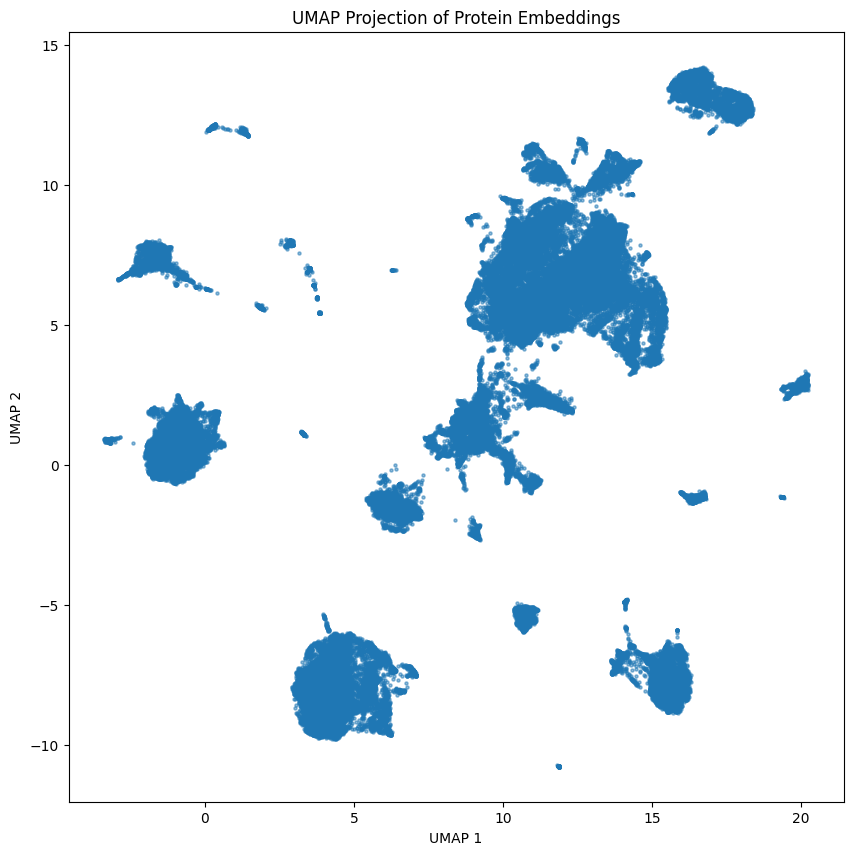

In [65]:
# visualize 
out = Path("../plots/first_plot.png")

plt.figure(figsize=(10, 10))

plt.scatter(df['x'], df['y'], s=5, alpha=0.5)
plt.title('UMAP Projection of Protein Embeddings')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.savefig(out, dpi=300, bbox_inches="tight")

plt.show()